# Discovery AI: Signature Discovery Practical

In this practical you will apply the signature discovery methods described in the lectures to a dataset to explore the types of signature they produce, and the effects that different choices have. 

## The Dataset

The dataset is a MALDI mass spectrometry image of a sagittal section of a rat cerebellum (part of the brain).

In MALDI (matrix-assisted laser desorption-ionisation) mass spectrometry, a laser is used to ablate material from a section of tissue that has been coated with a special chemical (the matrix) that enables effective energy transfer from the laser to the tissue. This process releases a gaseous plume of ionised molecules from the tissue that can them be analysed. MALDI is typically very good at extracting smaller molecules such as lipids and metabolites, and less good at extracting larger molecules such as proteins.

The gaseous plume of molecules is then aspirated into a mass spectrometer, which accelerates the ionised molecules towards a detector using a careful designed electromagnetic field. The acceleration of the particles is dependent on the ratio of their mass-to-charge ($m/z$) and so the arrival times of the ionised molecules can be used to determine $m/z$. As the plume of gas will contain many different molecules with different $m/z$ values, the measurement produces a *mass spectrum* that shows the abundance of molecules at different $m/z$ values.

This process can be repeated at many different points on a tissue section which allows us to construct a *mass spectrometry image* where at each pixel, we record a mass spectrum that contains detailed information about the chemical composition of the tissue at that location.

The dataset we will be working with comprises $62\times40$ pixels, each of which has a mass spectrum with 4865 $m/z$ values in it. Let's load this in and take a look.

In [13]:
import scipy.io
data = scipy.io.loadmat('signature.mat')
X = data['X'].transpose() 
mz = data['fileInfo'][0][0][8].squeeze()
print(f"Data array X is of size {X.shape}")

Data array X is of size (2480, 4865)


Let's display the data in a couple of ways. First, let's render an image to make sure we've read everything in correctly. We will display the "total ion count" (TIC image) by summing the spectrum at each pixel

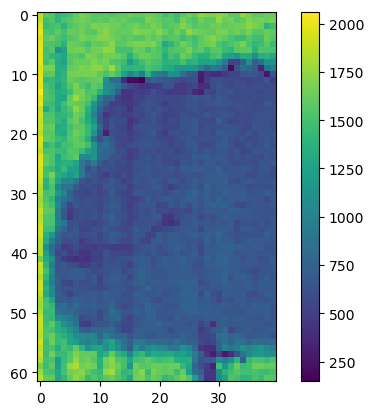

In [14]:
import numpy as np
import matplotlib.pyplot as plt
MSI = np.reshape(X,shape=[62,40,4865])
TICImage = MSI.sum(axis=2)
plt.imshow(TICImage)
plt.colorbar()


We have something that looks like an image of something which gives us confidence that we have read everything in correctly. Let's now plot a spectrum. Choose something from the middle of image, say row 30, column 20.

[Note that counting starts at 0 so rows are 0 to 61 and columns are 0 to 39.]

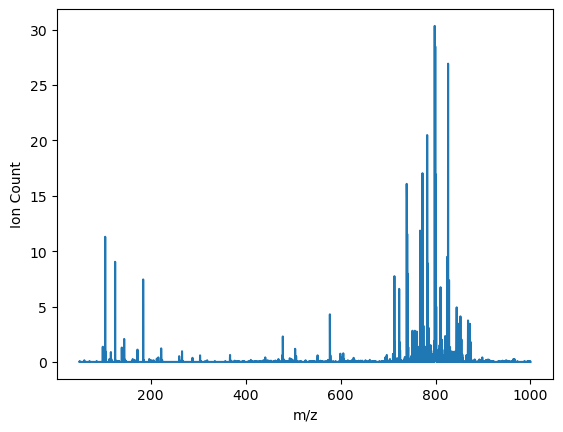

In [34]:
def plotSpectrum(mz,datacube,row, column):
    plt.plot(mz,datacube[row,column,:])
    plt.xlabel('m/z')
    plt.ylabel('Ion Count')
    plt.show()
    return None

plotSpectrum(mz,MSI,20,20)

## EXPLORE
Look at the spectra at different locations. How do they vary on/off tissue?

Now let's plot individual ions. There are 4865 $m/z$ channels so we can select between 0 and 4864

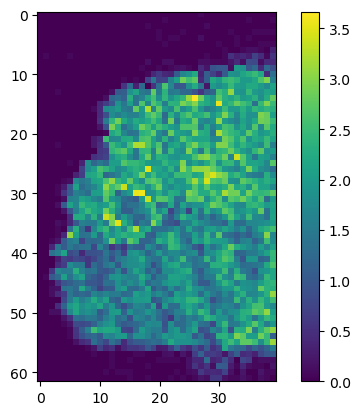

In [37]:
def plotIonImage(datacube, channel):
    plt.imshow(datacube[:,:,channel])
    plt.colorbar()
    plt.show()
    return None

plotIonImage(MSI, 3931)


## EXPLORE
Can you find channels that look interesting or informative? It is not very easy. Some interesting ones to look at are 2930, 3931, 4000, 4129.



## Prototype Learning

Let us now apply some of the ideas we consider in the lecture. We'll begin with prototype learning and start that with a supervised approach using Linear Discriminant Analysis.

Because LDA is a sueprvised approach, we will need to define some training data. To do this, we will need to select some phenomena/structures that we wish to identify. There are a great many different structures in this image that we could label, but we will keep things simple for now and label ten pixels that are off-tissue with label 0 and ten pixels that are on-tissue with label 1.

In [17]:
BackgroundPixels = [(1,3),(5,10),(4,20),(57,3),(18,2),(60,20),(55,5),(30,0),(5,30),(10,9)]
OnTissuePixels = [(20,20),(40,30),(25,15),(15,28),(48,22),(37,33),(32,10),(50,10),(18,24),(35,15)]
TrainingPixels = BackgroundPixels + OnTissuePixels
Classes = [0 for i in BackgroundPixels] + [1 for i in OnTissuePixels]
TrainingData = [MSI[i[0],i[1],:] for i in TrainingPixels]

Now we can create the classifier. We will use a library calle `scikit-learn` for this. This is by far the most common library for machine learning and it is very easy to use, with only three lines of code needed. 

In [18]:
import sklearn.discriminant_analysis as da
# Create an LDA classifier
LDA = da.LinearDiscriminantAnalysis()
# Train the classifier
LDA.fit(TrainingData, Classes)
# Apply to all pixels in the image
LDAPredictions = LDA.predict(X)

Let's check our predictions. The easiest and most natural way to do this is to simply plot the predictions as an image.

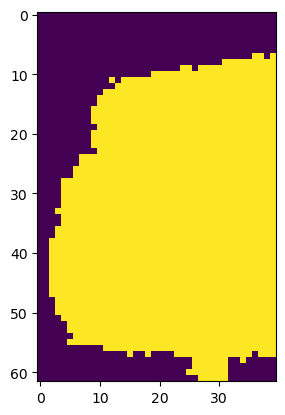

In [19]:
# Plot the predictions as an image
plt.imshow(np.reshape(LDAPredictions,(62,40)))

## EXPLORE

* Do these predictions look reasonable?
* What happens to the prediction if you increase/decrease the number of training points? How few points are sufficient to get clear separation?

What about the signatures? We can calculate these as the means of the training data.

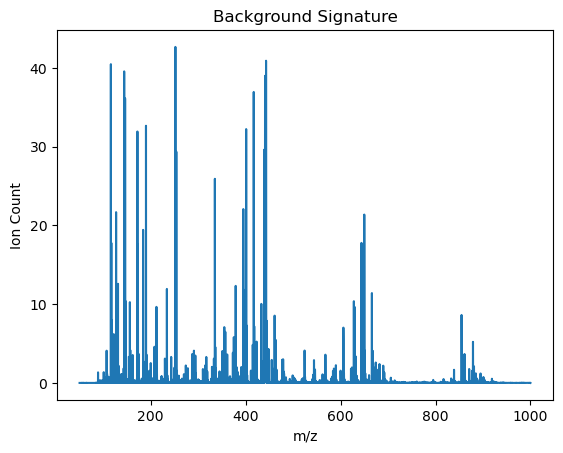

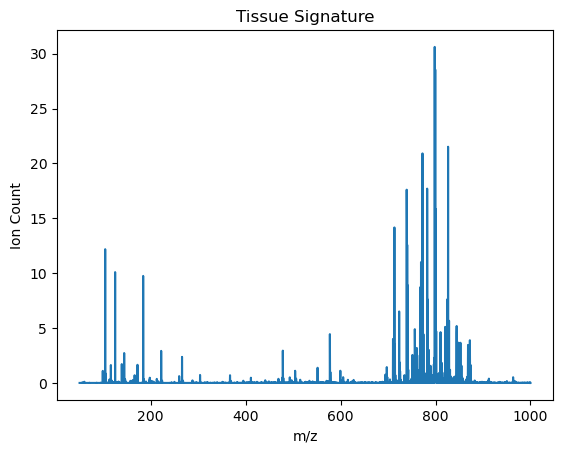

In [20]:
BackgroundSignature = np.array([MSI[i[0],i[1],:] for i in BackgroundPixels]).mean(axis=0)
TissueSignature = np.array([MSI[i[0],i[1],:] for i in OnTissuePixels]).mean(axis=0)
plt.plot(mz,BackgroundSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Background Signature')
plt.show()
plt.plot(mz,TissueSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Tissue Signature')
plt.show()

Do the predictions have the same signature as the training data? Lets find out.

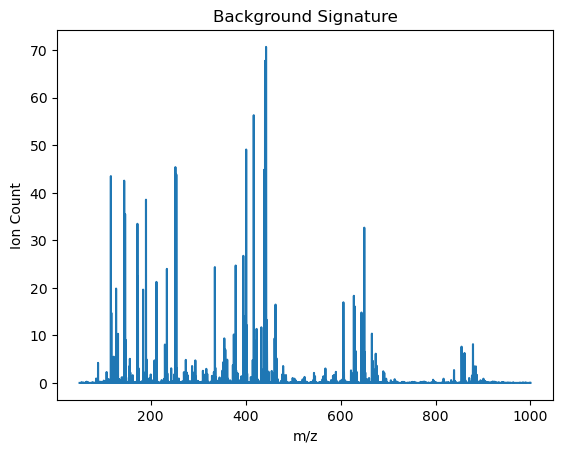

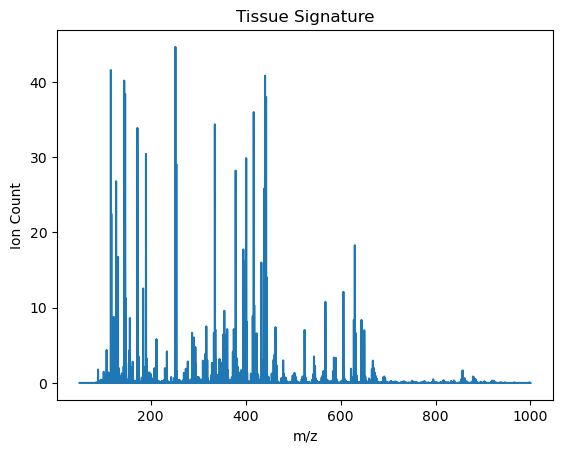

In [21]:
BackgroundSignature = np.array([X[i,:] for i in LDAPredictions if i==0]).mean(axis=0)
TissueSignature = np.array([X[i,:] for i in LDAPredictions if i==1]).mean(axis=0)
plt.plot(mz,BackgroundSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Background Signature')
plt.show()
plt.plot(mz,TissueSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Tissue Signature')
plt.show()

## EXPLORE

* How do the signature of the predictions compare to the signatures of the training data?
* Where are the key differences between the predictions of the two classes?
* How do the signature of the predictions vary as you change the training data?
* Can you think of a hypothesis that might explain your observations?

Now, LDA makes an assumption that the two class have the same covariance. This seems unlikely to be true in this case. Let us see what happens when we use a method, QDA, that does not make that assumption. The code is almost identical, except we replace `LinearDiscriminant` with `QuadraticDiscriminant`. For compactness, we will bring all of the code into a single cell.

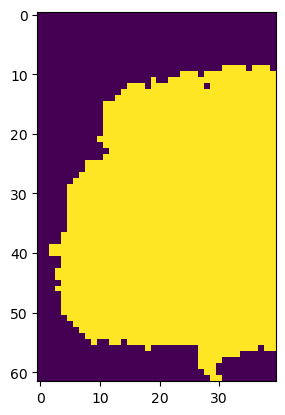

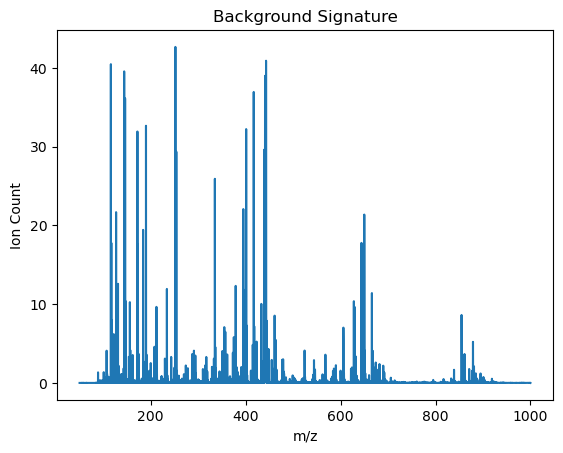

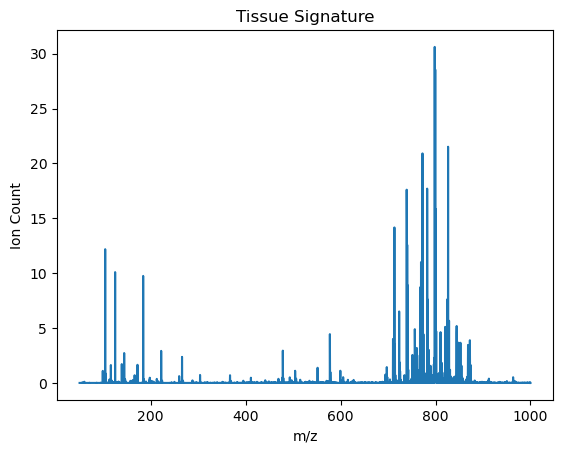

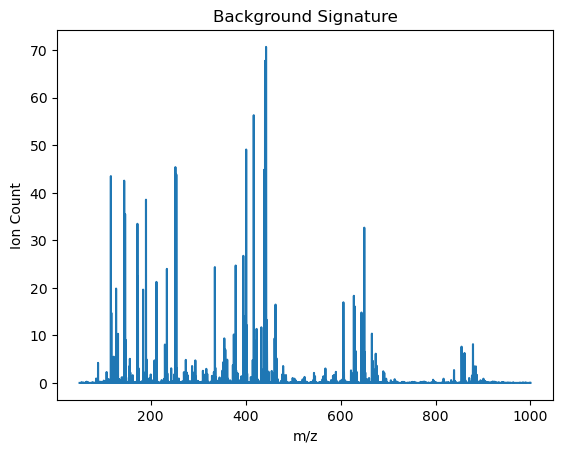

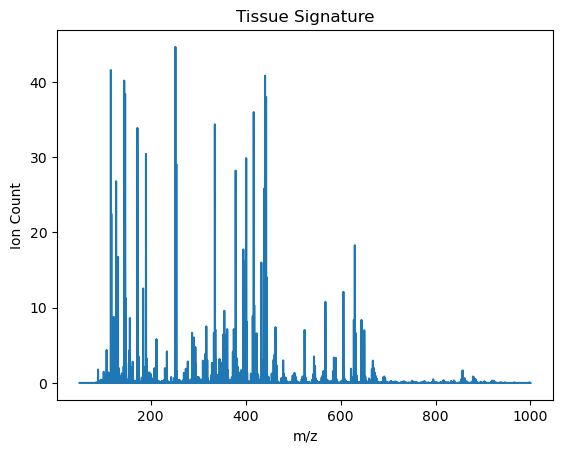

In [22]:
import sklearn.discriminant_analysis as da
# Create a QDA classifier. This requires some options to be specified
QDA = da.QuadraticDiscriminantAnalysis(solver='eigen',shrinkage='auto')
# Train the classifier
QDA.fit(TrainingData, Classes)
# Apply to all pixels in the image
QDAPredictions = QDA.predict(X)
# Plot the predictions as an image
plt.imshow(np.reshape(QDAPredictions,(62,40)))
plt.show()
# Plot the signatures of the training data (same as LDA)
BackgroundSignature = np.array([MSI[i[0],i[1],:] for i in BackgroundPixels]).mean(axis=0)
TissueSignature = np.array([MSI[i[0],i[1],:] for i in OnTissuePixels]).mean(axis=0)
plt.plot(mz,BackgroundSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Background Signature')
plt.show()
plt.plot(mz,TissueSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Tissue Signature')
plt.show()
# plot the predicted signatures
QBackgroundSignature = np.array([X[i,:] for i in QDAPredictions if i==0]).mean(axis=0)
QTissueSignature = np.array([X[i,:] for i in QDAPredictions if i==1]).mean(axis=0)
plt.plot(mz,QBackgroundSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Background Signature')
plt.show()
plt.plot(mz,QTissueSignature)
plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title('Tissue Signature')
plt.show()

## EXPLORE

* How do the predictions compare with those of LDA?

## Unsupervised Prototype Learning

Fit directly on data matrix X

In [44]:
import sklearn.cluster as cluster
# Create a k-means clusterer. This requires us to specify the number of clusters
n_clusters = 6
KM = cluster.KMeans(n_clusters=n_clusters)
# Run the clustering method
KM.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Plot the resulting clusters. Note that the clusters could be in any order, so so we shouldn't expect the colours to be the same as we saw in LDA.

[1 1 1 ... 3 3 3]


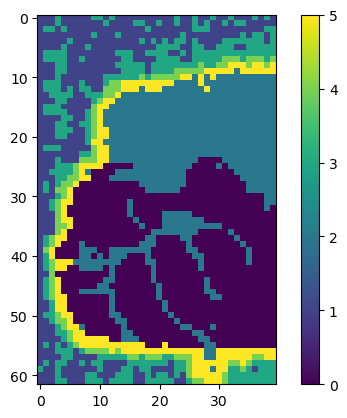

In [45]:
print(KM.labels_)
# Apply to all pixels in the image
# Plot the predictions as an image
plt.imshow(np.reshape(KM.labels_,(62,40)))
plt.colorbar()
plt.show()


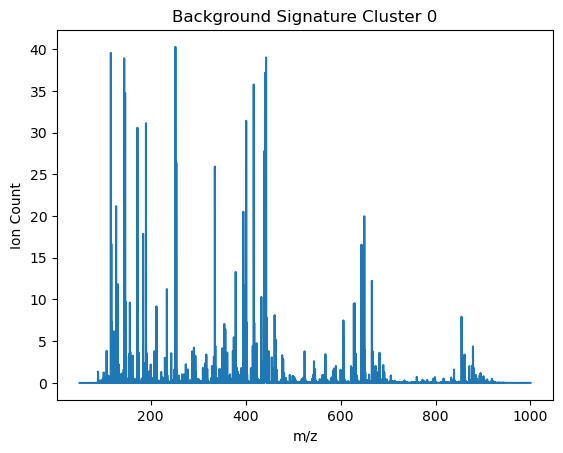

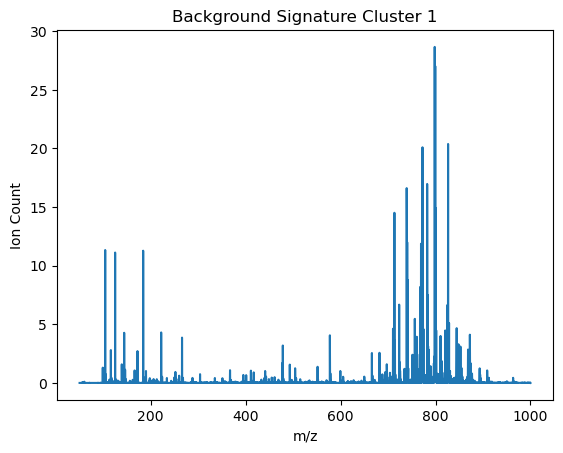

In [25]:
# Plot the signatures of the cluster. These are the centroids of the clusters
for i, centroid in enumerate(KM.cluster_centers_):
    plt.plot(mz,centroid)
    plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title(f'Background Signature Cluster {i}')
    plt.show()


## EXPLORE

* Can k-means identify structure in the data?
* How do the results compare to those obtained using supervised methods?
* What happens when you change the number of clusters? Can you identify any more subtle structures in the data that cannot be clearly seen in the total ion count image?

## Decompositions

We'll now explore some decompostion-based approached to signature discovery. We'll start with Principal Component Analysis which, recall, represents the data in terms of a set of components that are selected to align with the directions of variation in the data.

As with LDA and k-means, PCA is very easy to do in `sklearn`:

In [26]:
import sklearn.decomposition as decomp
PCA = decomp.PCA()
PCA.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

One of the properties of PCA is that it is aligned with with the structure of the data by sequentially choosing the directions of greatest variance in the data. It is useful to see how the proportion of explained variance changes with the number of components:

Text(0, 0.5, 'Proportion of Explained Variance')

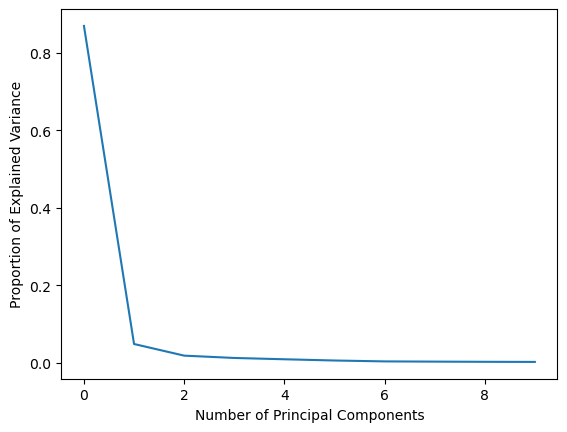

In [27]:
cutoff = 10 
plt.plot(PCA.explained_variance_ratio_[0:cutoff])
plt.xlabel('Number of Principal Components')
plt.ylabel('Proportion of Explained Variance')

It is often better to plot the cumulative sum of the variance so we can see how it approached 1.

Text(0, 0.5, 'Cumulative Sum of Explained Variance')

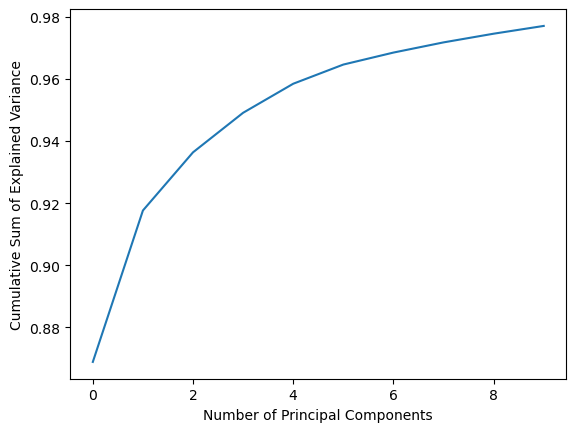

In [28]:
cutoff = 10
plt.plot(np.cumsum(PCA.explained_variance_ratio_[0:cutoff]))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Sum of Explained Variance')


Let us now look at the signatures that have been learned - the principal components

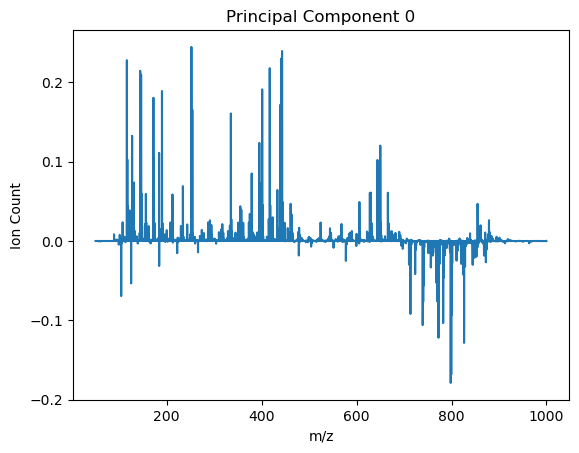

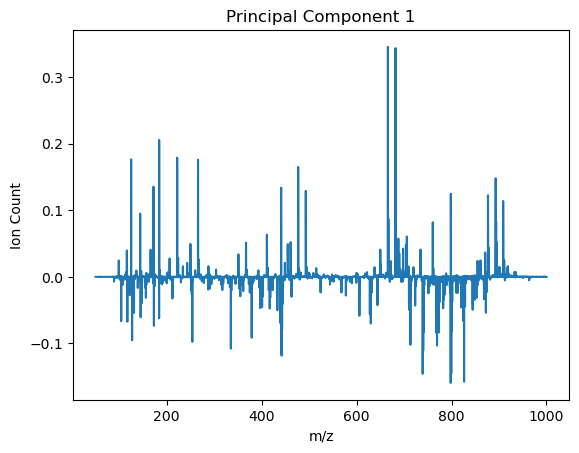

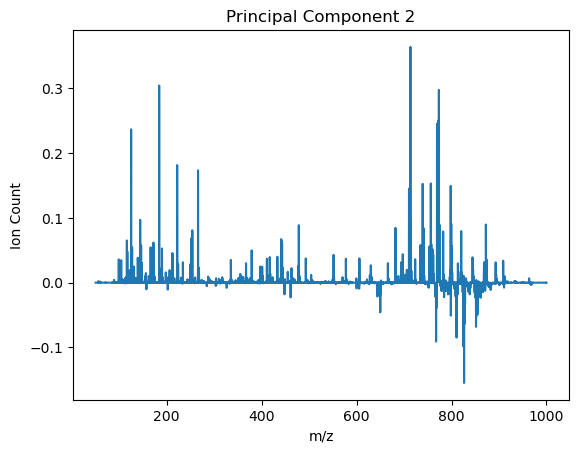

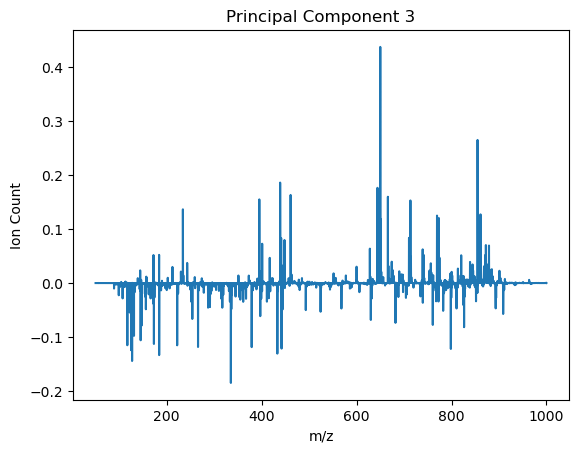

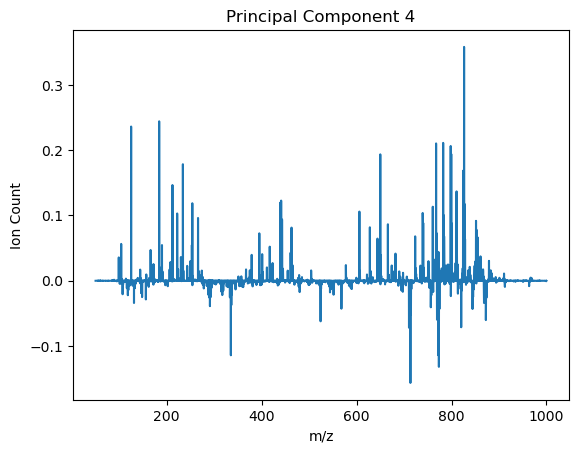

In [29]:
cutoff = 5
for i in range(cutoff):
    plt.plot(mz,PCA.components_[i])
    plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title(f'Principal Component {i}')
    plt.show()

    

## EXPLORE

* How many components do you think represent the natural varation in the data
* What similarities are differences are there between the principal components and the signatures that were found by k-means?
* How do the components change as the proportion of variance that they explain decrease?

Now, let's transform the data onto the principal components. We project the data onto the principal components and then plot the projections as images.

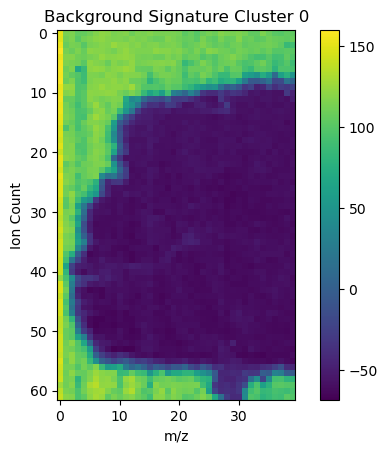

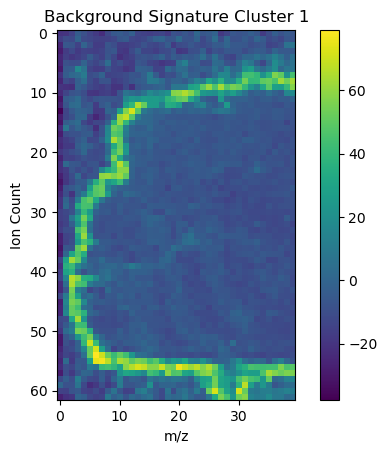

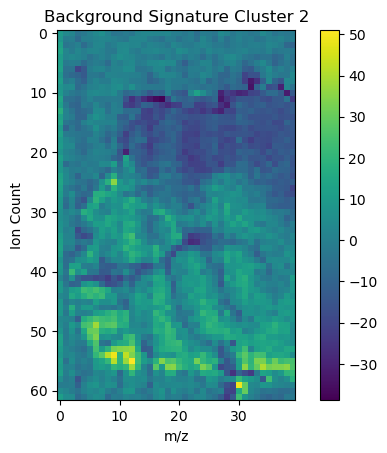

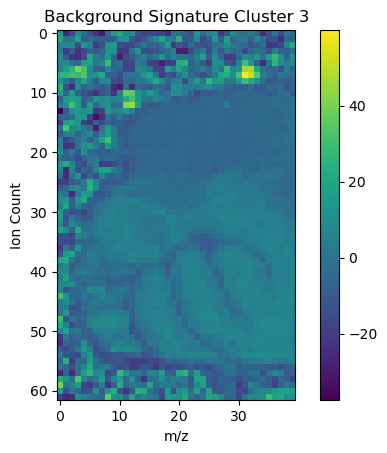

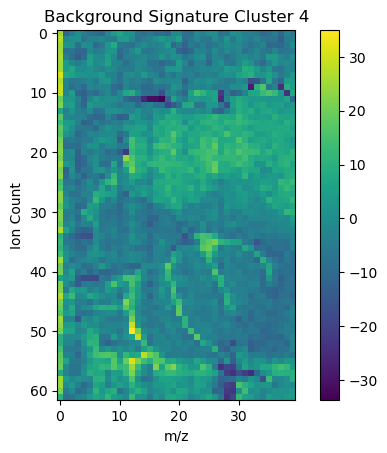

In [30]:
n_components = 5
TransformedData = PCA.transform(X)
for i in range(n_components):
    x = TransformedData[:,i]
    plt.imshow(np.reshape(x,(62,40)))
    plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title(f'Background Signature Cluster {i}')
    plt.colorbar()
    plt.show()

## EXPLORE

* Compare and contrast the projections with the patterns that can be seen in k-means. Are there similarities?
* Compare and contrast the signature of cluster and projections with similar spatual patterns? Are the signatures similar?
* What happens if you retain more components? Do any of the lower variance components reveal interesting structure?

## Nonnegative Matrix Factorisation

Now let's see what non-negative matrix factorisation does on this dataset. One different between NMF and PCA is that we have to explicitly state how many components we want. Let's choose 10 initially, but you can vary this:

In [31]:
import sklearn.decomposition as decomp
x_components = 10
NMF = decomp.NMF(n_components=n_components)
NMF.fit(X)

/opt/anaconda3/envs/DiscoveryAI/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary `.",None
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


Let's plot the factors. These should all be non-negative.

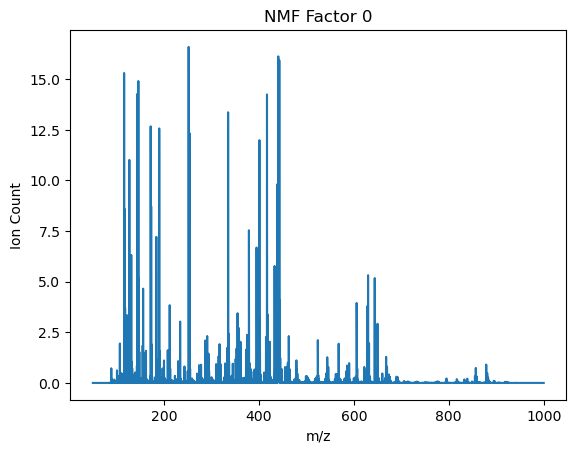

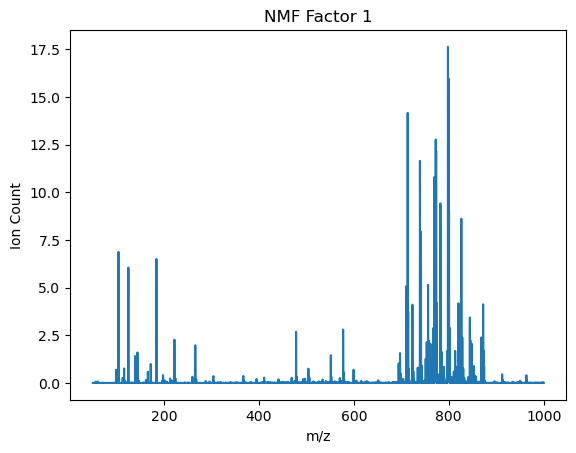

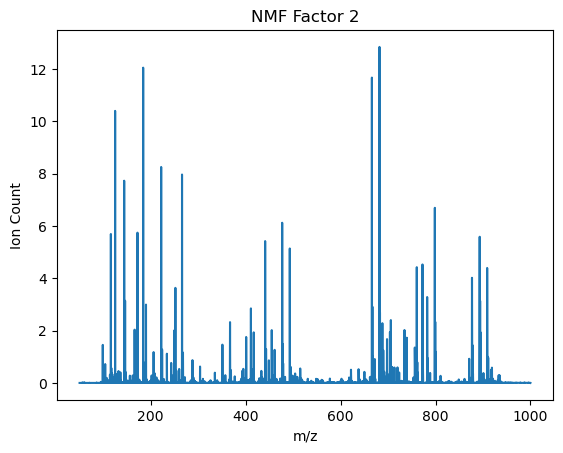

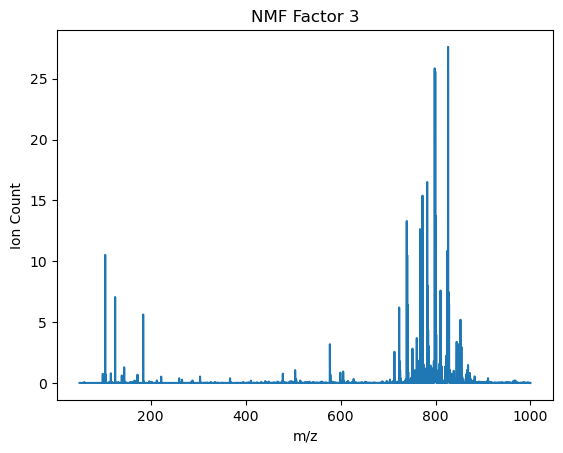

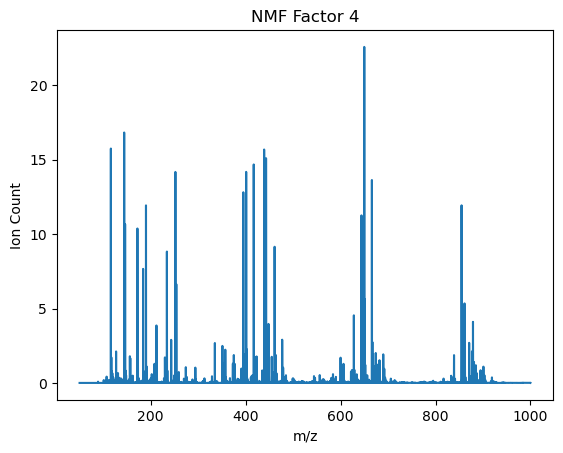

In [32]:
for i in range(n_components):
    plt.plot(mz,NMF.components_[i])
    plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title(f'NMF Factor {i}')
    plt.show()

## EXPLORE

* How do these factors compare with those derived with the other methods?
* Does adding additional factors get you more information?

Now, we plot the projections of the data onto the factors

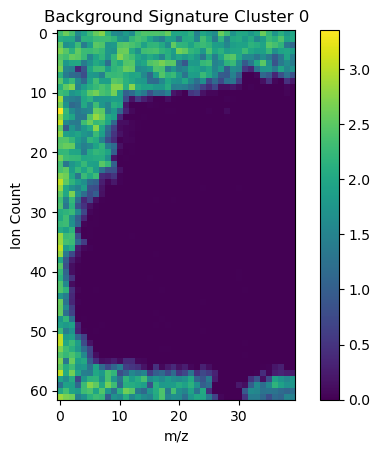

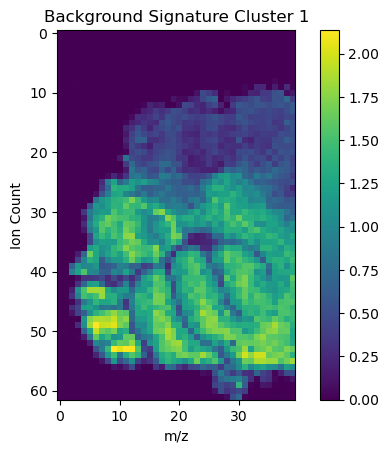

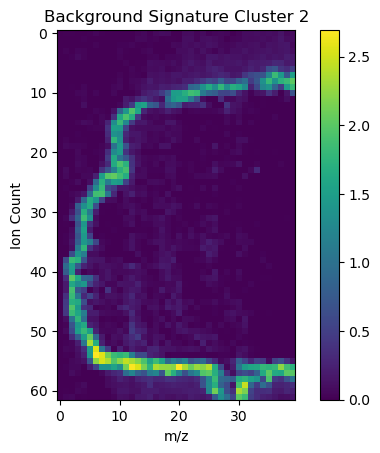

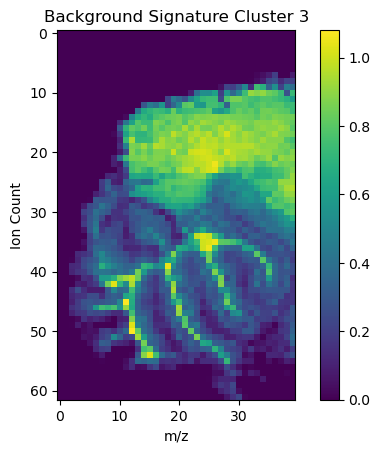

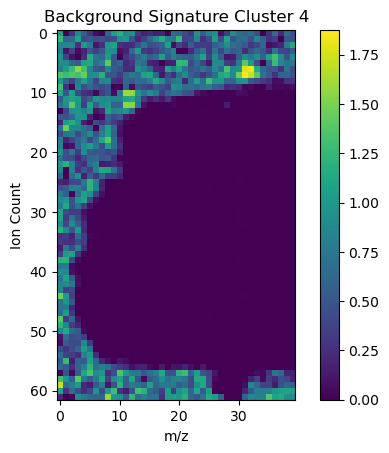

In [33]:
TransformedNMFData = NMF.transform(X)
for i in range(n_components):
    x = TransformedNMFData[:,i]
    plt.imshow(np.reshape(x,(62,40)))
    plt.xlabel('m/z'), plt.ylabel('Ion Count'), plt.title(f'Background Signature Cluster {i}')
    plt.colorbar()
    plt.show()

## EXPLORE

* How do the spatial patterns of the factors compare with those derived by other approaches?

## Wrap-up

We have explored several different approaches to signature discovery here

* Which one is right for your circumstance depends on the nature of the problem and what information you have available (was LDA/QDA a good choice here?)
* Unsupervised prototype learning gives coarser but perhaps more generalisable results that decompositions
* In this application, PCA is hard to interpret
* NMF gives very good results but requires some knowledge of how many signatures we a looking for
* **Which approach do you like for this problem?**
* **Which approaches might be relevant to your research?**